In [18]:
%run "../../scripts/01-check_setup.ipynb"

SAP HANA Client for Python: 2.29.26061601
Using the dot-env file /Users/I076835/Repositories/GitHub/hana-ai-ve-kg-codejam/.env
Connected to SAP HANA db version 4.00.000.00.1782206579 (fa/CE2026.14) 
at c5889dd5-e0f6-4930-8408-94d53ca61dbf.hna0.prod-us10.hanacloud.ondemand.com:443 as CODEJAMHANAAI00
Current time on the SAP HANA server: 2026-07-09 11:13:38.501000


In [25]:
import os
import pandas as pd

file_path = "agenda_hanatechcon_2026.html"

with open(file_path, "r", encoding="utf-8") as f:
    html_content = f.read()

print(f"Loaded {len(html_content):,} characters from {file_path}")

Loaded 897,555 characters from agenda_hanatechcon_2026.html


In [26]:
df_event = pd.DataFrame([{
    "metadata": str({"file_name": file_path}),
    "content_html": html_content
}])
df_event = df_event.convert_dtypes()
display(df_event.dtypes)
df_event

metadata        string[python]
content_html    string[python]
dtype: object

,metadata,content_html
0,{'file_name': 'agenda_hanatechcon_2026.html'},"<!DOCTYPE html>\n<html lang=""en"">\n<head>\n<meta charset=""UTF-8"">\n<title>HTC2026 Agenda</title>\n</head>\n<body>\n<h1>From Bold Promises to Operational Reality – A Community-Driven Journey</h1>\n<p>9:00–9:40</p>\n<p>Audimax</p>\n<p>SAP HANA: From Bold..."



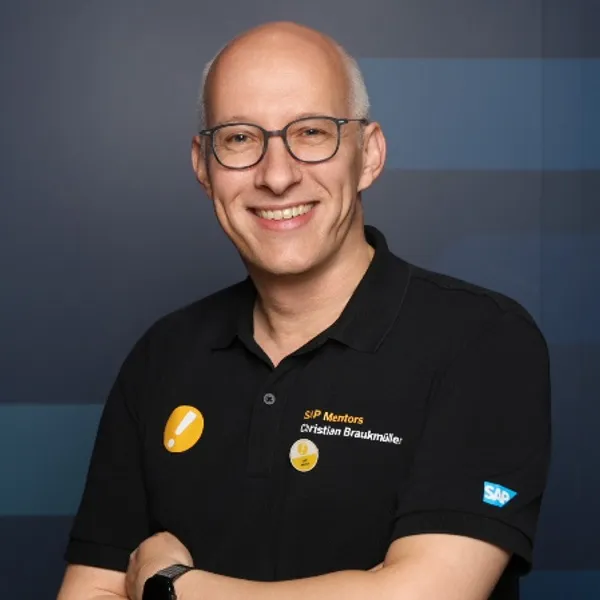
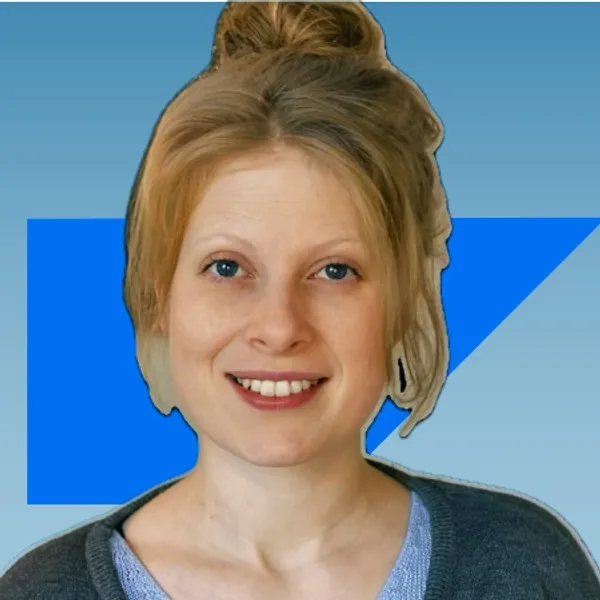
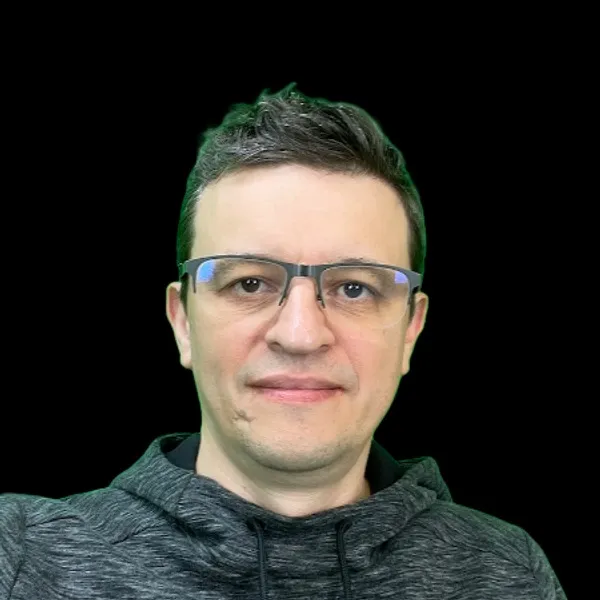
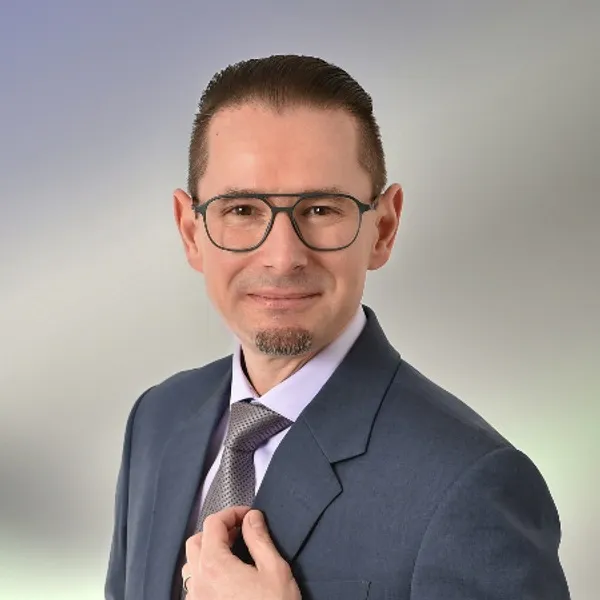
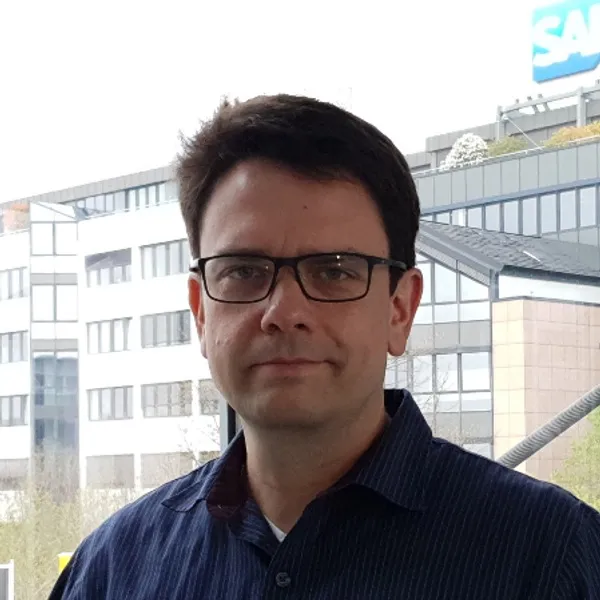
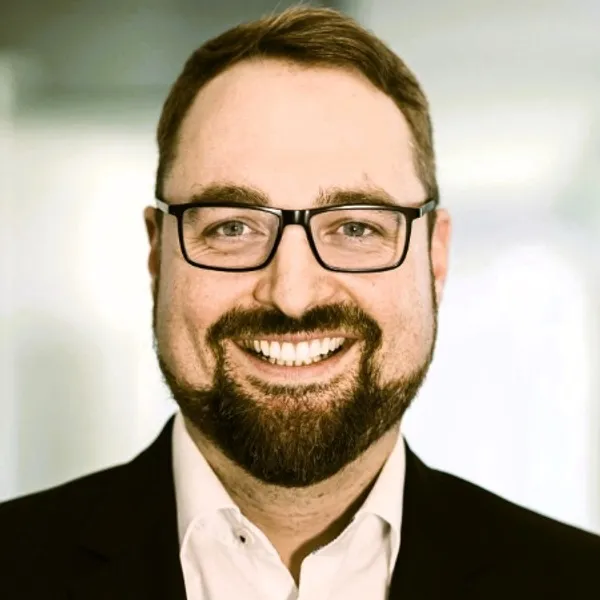
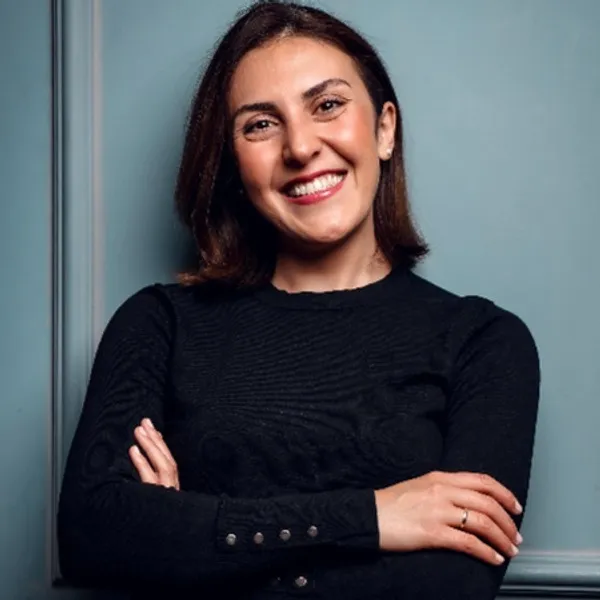
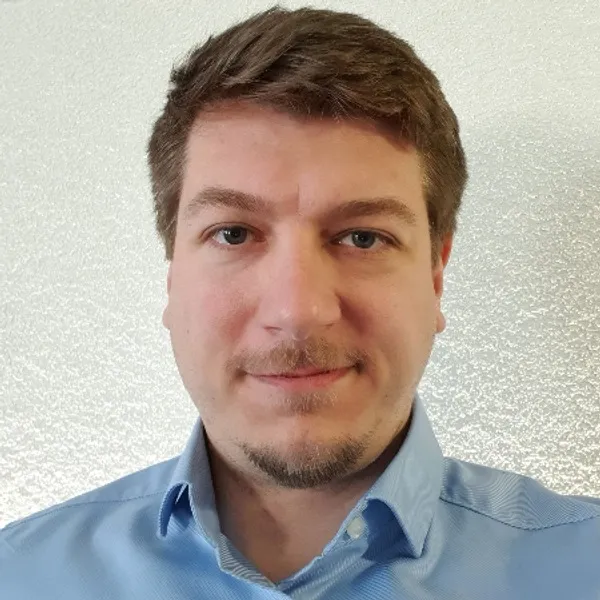
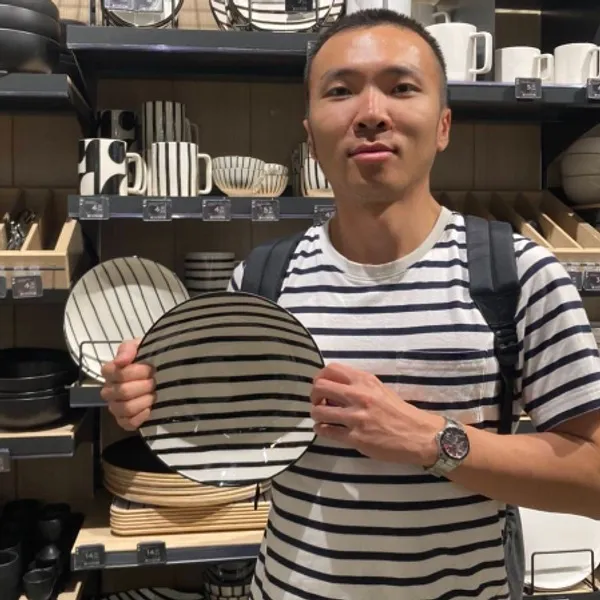
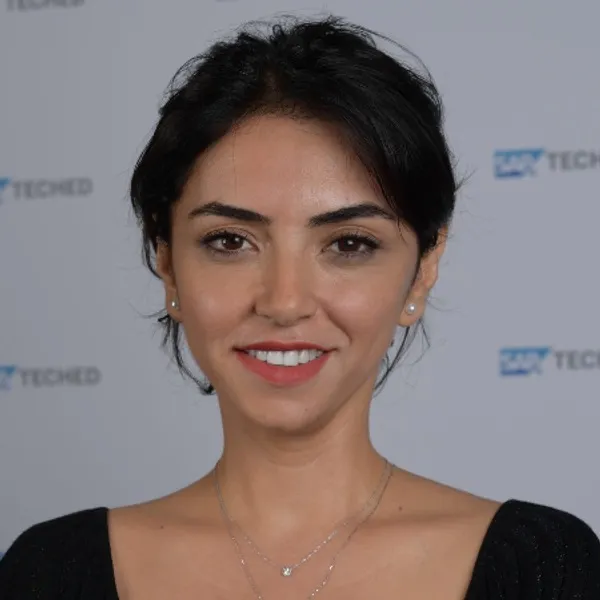
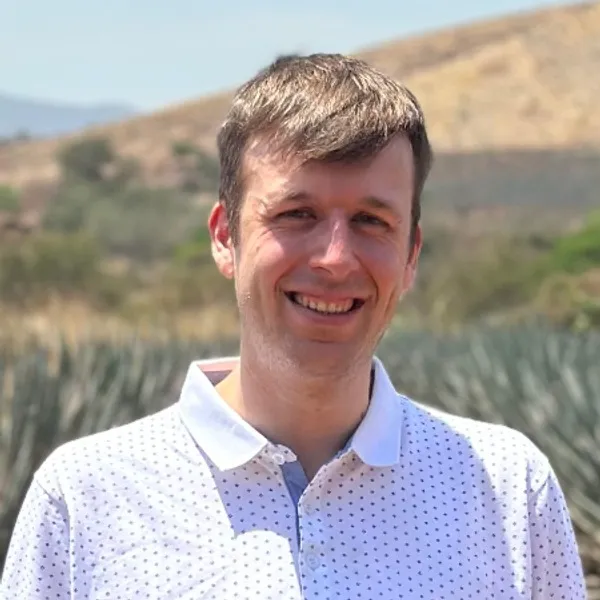
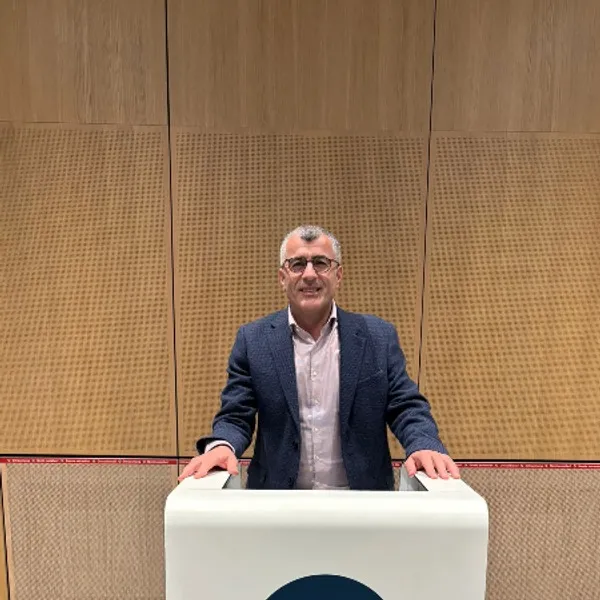
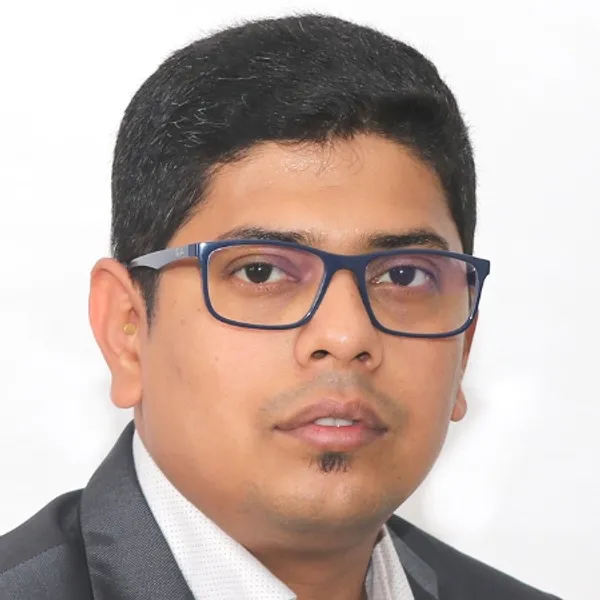
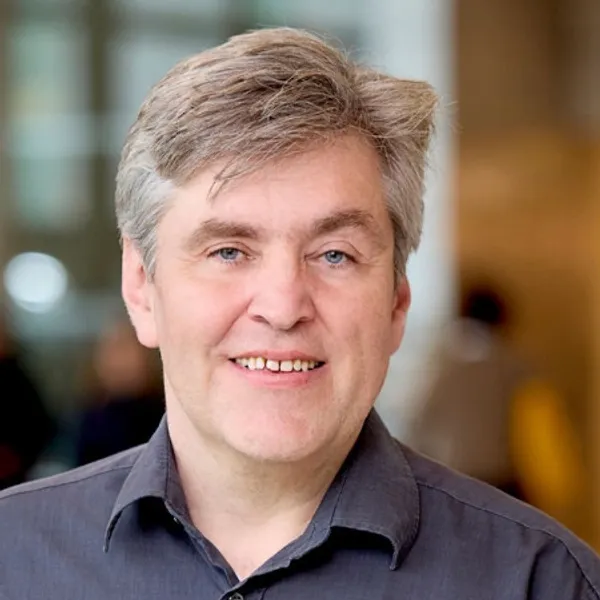
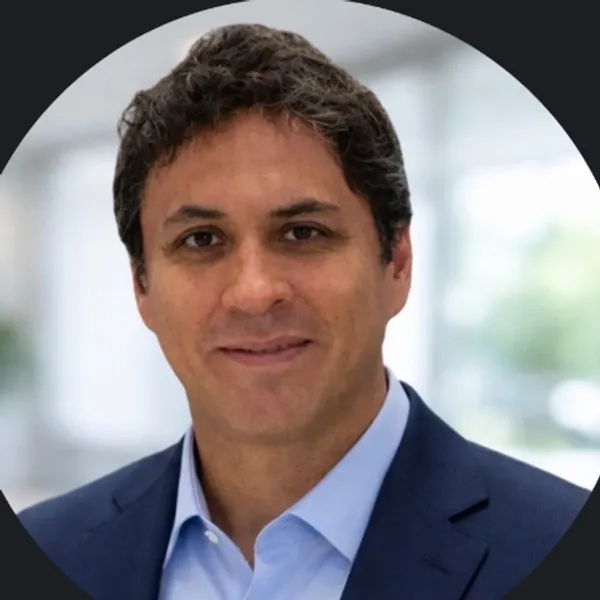
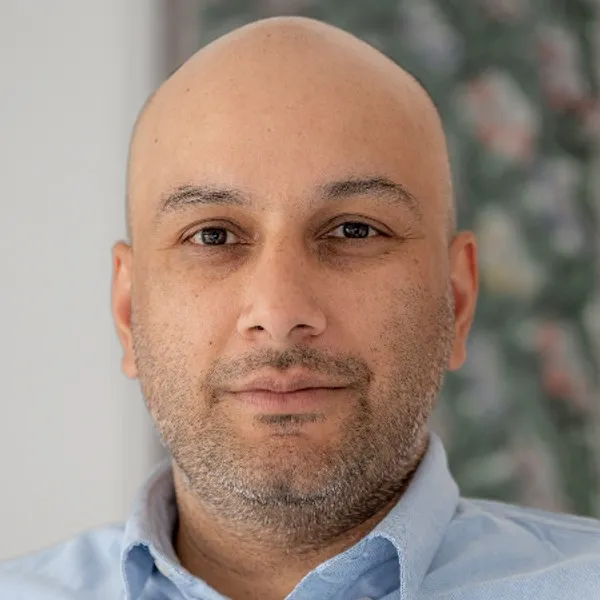
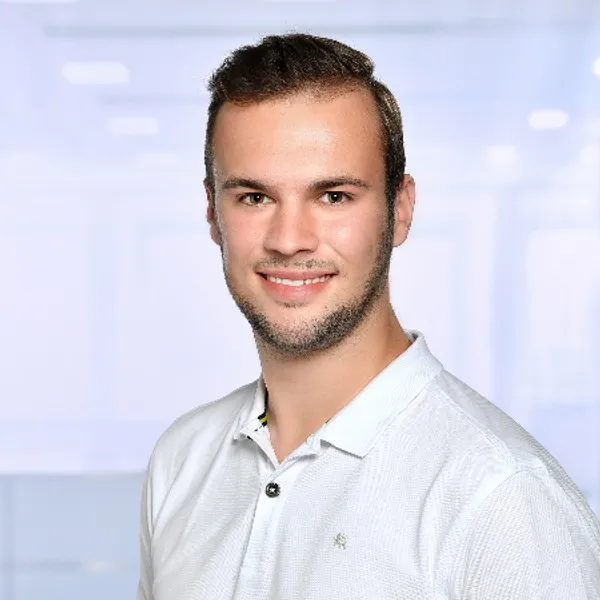
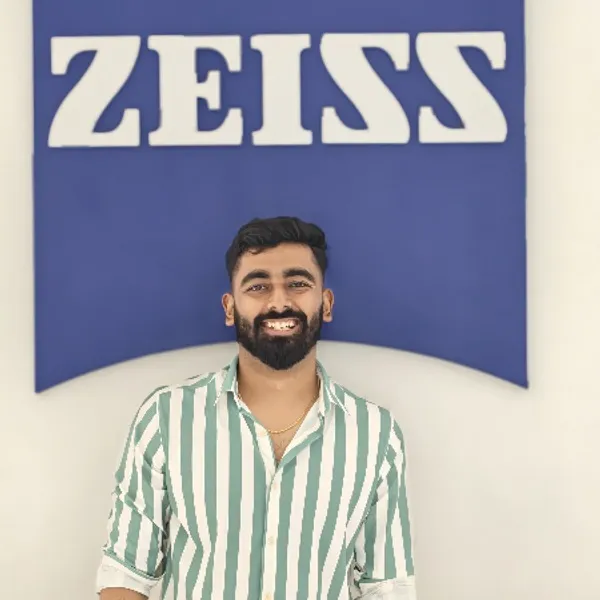
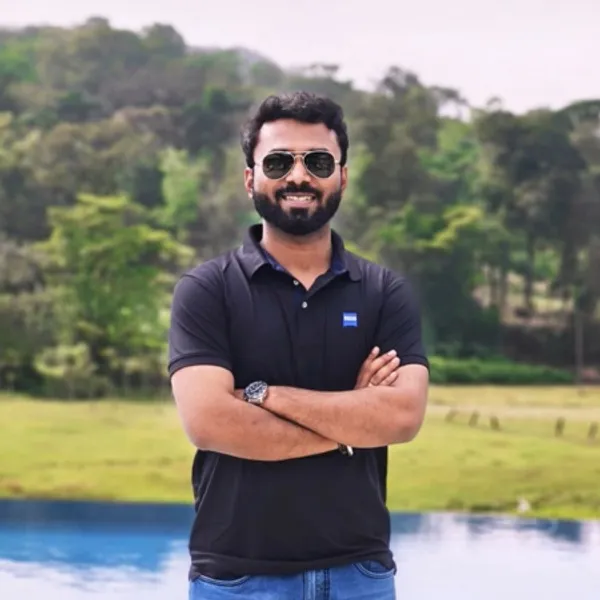
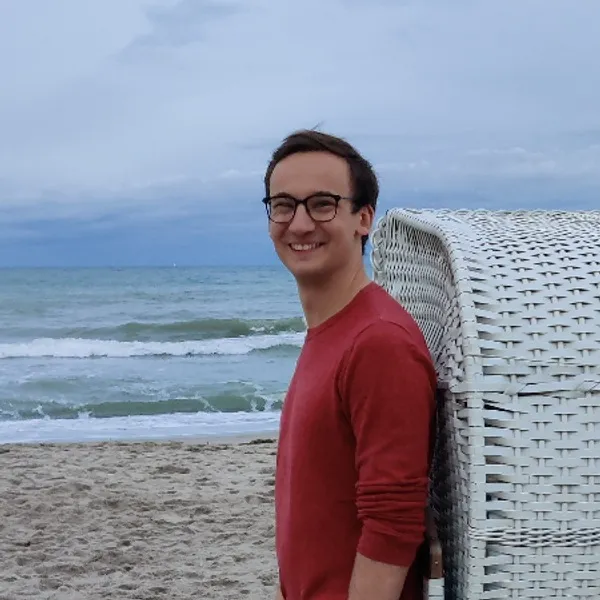
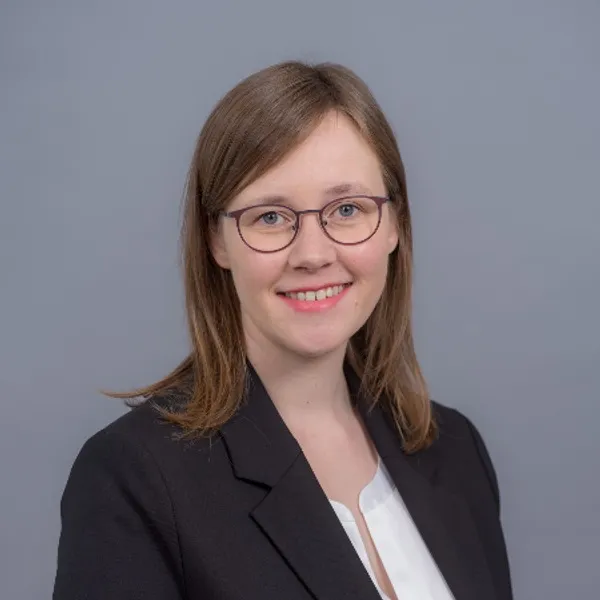
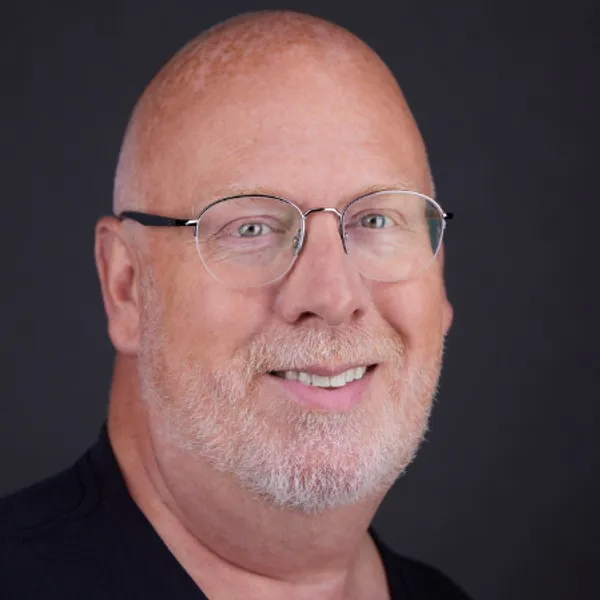
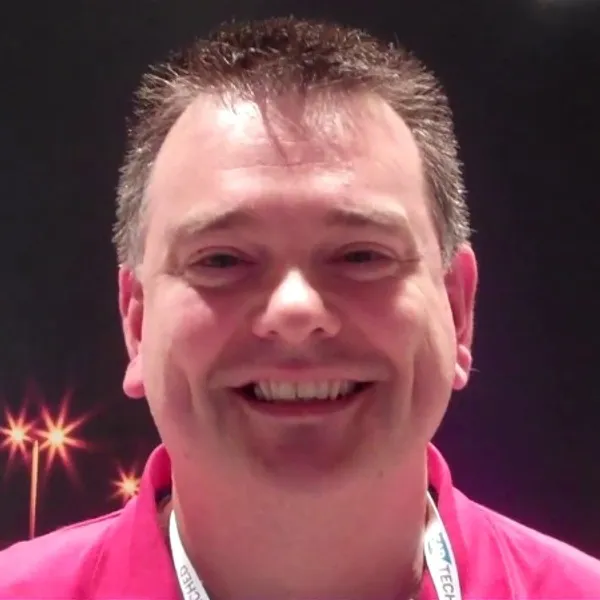
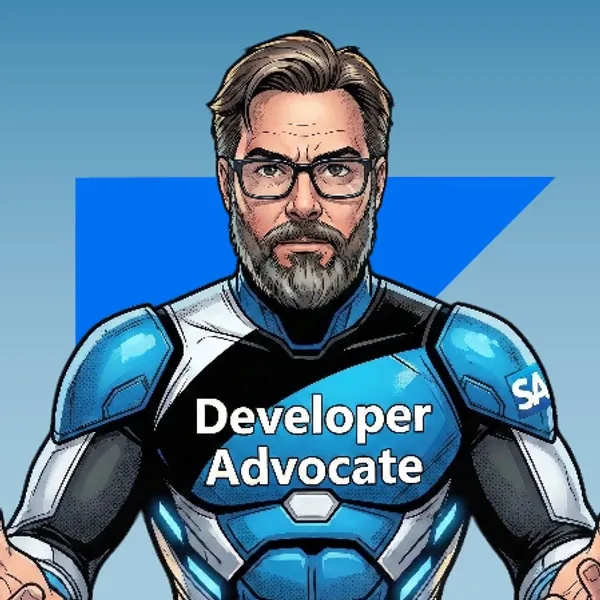
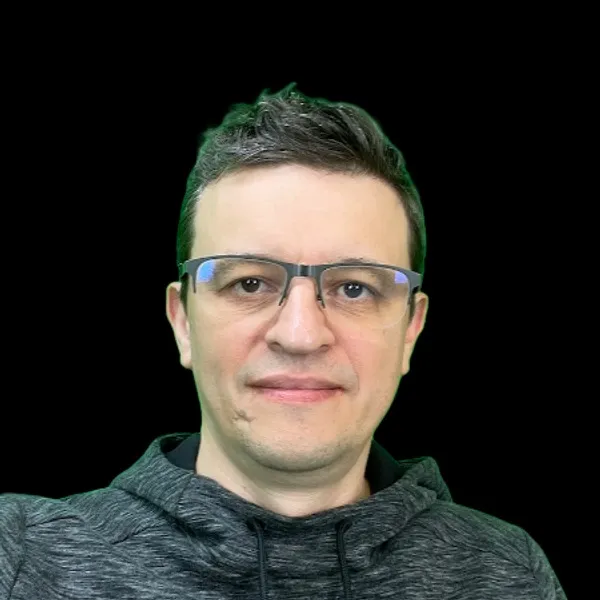

In [27]:
import markdown
from IPython.display import HTML

# Convert Markdown to HTML
html = markdown.markdown(df_event['content_html'][0])

display(HTML(html))


In [28]:
hana_table_name = "CODECONNECT"
hana_schema_name = "VECTORS"

In [29]:
from hana_ml.dataframe import create_dataframe_from_pandas

hdf_event_bronze = create_dataframe_from_pandas(
    connection_context=myconn,
    pandas_df=df_event,
    table_name=hana_table_name,
    schema=hana_schema_name,
    force=True,
    object_type_as_bin=True,
    table_structure={"metadata": "NVARCHAR(5000)", "content_html": "NCLOB"}
)

100%|██████████| 1/1 [00:00<00:00,  2.43it/s]


In [30]:
pd.set_option("max_colwidth", 256)
hdf_event_bronze.head().collect().T

,0
metadata,{'file_name': 'agenda_hanatechcon_2026.html'}
content_html,"<!DOCTYPE html>\n<html lang=""en"">\n<head>\n<meta charset=""UTF-8"">\n<title>HTC2026 Agenda</title>\n</head>\n<body>\n<h1>From Bold Promises to Operational Reality – A Community-Driven Journey</h1>\n<p>9:00–9:40</p>\n<p>Audimax</p>\n<p>SAP HANA: From Bold..."
